# Mini-Challenge 1: Retrieval Augmented Generation

This notebook implements a RAG system to answer questions based on the EDW Aviation PDFs provided.
We will systematically build and evaluate our RAG pipeline through various experiments, always keeping the best configuration for the next step.

Project layout: `data/` stores the EDW manuals, the evaluation set, and the saved FAISS index. `task/` stores the challenge brief and reference PDFs.

**Models & Stack used:**
- Framework: LangChain
- LLMs: `gpt-5-mini` and `gpt-5-nano`
- Embeddings: `text-embedding-3-small` and `text-embedding-3-large`
- Evaluator: `gpt-5` (used for LLM-as-a-judge)
- Vector DB: FAISS


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib"))

import json
import queue
import re
import threading
import warnings
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
import random
import math

# Fix FAISS OMP crash on apple silicon/macOS
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from typing import List, Dict
from pypdf import PdfReader
from tqdm import tqdm
from unstructured.chunking.title import chunk_by_title
from unstructured.documents.elements import NarrativeText, Title

from dotenv import load_dotenv
load_dotenv()

DATA_DIR = "data"
TASK_DIR = "task"
FAISS_INDEX_DIR = os.path.join(DATA_DIR, "faiss_index")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(TASK_DIR, exist_ok=True)

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_text_splitters import RecursiveCharacterTextSplitter


**Expectations:** The environment initializes properly and the required libraries are ready for use.

## 1. Data
Load the EDW PDFs into a single text corpus to be processed by our RAG system.


In [2]:
MANUAL_NAME_MAP = {
    "EDW FCTM A340.pdf": "FCTM",
    "EDW OM A.pdf": "OM A",
    "EDW QRH A340.pdf": "QRH",
    "EDW CSPM.pdf": "CSPM"
}

MANUAL_SECTION_PREFIX = {
    "FCTM": "FCTM",
    "OM A": "OMA",
    "QRH": "QRH",
    "CSPM": "CSPM"
}

NUMBERED_SECTION_PATTERN = re.compile(r"^(\d+(?:\.\d+)*)\s+(.*)$")
QRH_SECTION_PATTERN = re.compile(r"^((?:[A-Z]+(?:-[A-Z]+)*)?)-(\d+(?:\.\d+)?[A-Z]?)\s+(.*)$")
QRH_CHAPTER_PATTERN = re.compile(r"^(ABN(?:-[A-Z]+)*|MEL|SUPP|INFO)\s*$")
PAGE_ID_PATTERN = re.compile(r"^(\d+(?:\.\d+)?[A-Z]?)$")


def split_numbered_manual_page(page_text: str, manual_name: str, current_section: str | None) -> tuple[list[Document], str | None]:
    documents = []
    matches = list(NUMBERED_SECTION_PATTERN.finditer(page_text))

    if not matches:
        if page_text.strip():
            metadata = {"manual": manual_name}
            if current_section:
                metadata["section"] = current_section
            documents.append(Document(page_content=page_text.strip(), metadata=metadata))
        return documents, current_section

    for idx, match in enumerate(matches):
        start = match.start()
        end = matches[idx + 1].start() if idx + 1 < len(matches) else len(page_text)
        section_text = page_text[start:end].strip()
        section_number = match.group(1)
        current_section = f"{MANUAL_SECTION_PREFIX[manual_name]}-{section_number}"
        documents.append(
            Document(
                page_content=section_text,
                metadata={"manual": manual_name, "section": current_section},
            )
        )

    return documents, current_section


def split_qrh_page(page_text: str, current_section: str | None) -> tuple[list[Document], str | None]:
    documents = []
    current_qrh_prefix = current_section.rsplit("-", 1)[0] if current_section and "-" in current_section else MANUAL_SECTION_PREFIX["QRH"]

    for raw_line in page_text.splitlines():
        chapter_match = QRH_CHAPTER_PATTERN.match(raw_line.strip())
        if chapter_match:
            current_qrh_prefix = f"{MANUAL_SECTION_PREFIX['QRH']}-{chapter_match.group(1)}"
            break

    matches = list(QRH_SECTION_PATTERN.finditer(page_text))

    if not matches:
        for raw_line in page_text.splitlines():
            parts = raw_line.strip().split(maxsplit=1)
            if len(parts) != 2 or not PAGE_ID_PATTERN.match(parts[0]):
                continue
            page_id = parts[0]
            current_section = f"{current_qrh_prefix}-{page_id}"
            documents.append(
                Document(
                    page_content=raw_line.strip(),
                    metadata={"manual": "QRH", "section": current_section},
                )
            )
        if documents:
            return documents, current_section
        if page_text.strip():
            metadata = {"manual": "QRH"}
            if current_section:
                metadata["section"] = current_section
            documents.append(Document(page_content=page_text.strip(), metadata=metadata))
        return documents, current_section

    for idx, match in enumerate(matches):
        start = match.start()
        end = matches[idx + 1].start() if idx + 1 < len(matches) else len(page_text)
        section_text = page_text[start:end].strip()
        section_prefix = match.group(1)
        page_id = match.group(2)
        if section_prefix:
            current_qrh_prefix = f"{MANUAL_SECTION_PREFIX['QRH']}-{section_prefix}"
        current_section = f"{current_qrh_prefix}-{page_id}"
        documents.append(
            Document(
                page_content=section_text,
                metadata={"manual": "QRH", "section": current_section},
            )
        )

    return documents, current_section


def split_fctm_page(page_text: str, current_section: str | None) -> tuple[list[Document], str | None]:
    if not page_text.strip():
        return [], current_section
    metadata = {"manual": "FCTM"}
    if current_section:
        metadata["section"] = current_section
    return [Document(page_content=page_text.strip(), metadata=metadata)], current_section


def load_edw_manual_documents(data_dir: str) -> list[Document]:
    documents = []
    docs_loaded = 0

    for filename in sorted(os.listdir(data_dir)):
        if not filename.lower().endswith(".pdf"):
            continue

        manual_name = MANUAL_NAME_MAP.get(filename, os.path.splitext(filename)[0])
        pdf_path = os.path.join(data_dir, filename)
        print(f"Loading {filename}...")
        reader = PdfReader(pdf_path)
        current_section = None

        for page in reader.pages:
            page_text = (page.extract_text() or "").strip()
            if not page_text:
                continue

            if manual_name == "FCTM":
                page_docs, current_section = split_fctm_page(page_text, current_section)
            elif manual_name in {"OM A", "CSPM"}:
                page_docs, current_section = split_numbered_manual_page(page_text, manual_name, current_section)
            else:
                page_docs, current_section = split_qrh_page(page_text, current_section)

            documents.extend(page_docs)

        docs_loaded += 1

    print(f"Loaded {docs_loaded} EDW documents.")
    return documents


manual_documents = load_edw_manual_documents(DATA_DIR)
pdf_text = "\n\n".join(doc.page_content for doc in manual_documents)
print(f"Created {len(manual_documents)} metadata-aware source documents.")
print(f"Total characters loaded: {len(pdf_text)}")
print("Sample metadata:", manual_documents[0].metadata)


Loading EDW CSPM.pdf...
Loading EDW FCTM A340.pdf...
Loading EDW OM A.pdf...
Loading EDW QRH A340.pdf...
Loaded 4 EDW documents.
Created 1825 metadata-aware source documents.
Total characters loaded: 2568988
Sample metadata: {'manual': 'CSPM'}


**Expectations:** The 4 EDW files should be loaded, resulting in a large string containing the extracted text.

**Source metadata note:** The corpus is loaded as metadata-aware documents. Each source document stores only the citation fields needed later: `manual` and `section`.

## 2. Gold Standart Evaluation Set
This gold-standard evaluation set contains 100 human-curated question-answer-context-meta entries drawn from the EDW manuals. It is intentionally balanced by manual length and topic coverage, with 30 items each from FCTM, OM A and CSPM, and 10 from the shorter QRH. Each item uses a single supporting passage and a compact manual-section label so retrieval quality and answer grounding can be evaluated independently of chunking.


In [3]:
with open(os.path.join(DATA_DIR, 'gold_standard_triplets_100_v2.json'), 'r', encoding='utf-8') as f:
    qa_pairs = json.load(f)

print(f"Loaded {len(qa_pairs)} Q&A pairs for evaluation.")
print("Sample pair:")
print(qa_pairs[0])


Loaded 100 Q&A pairs for evaluation.
Sample pair:
{'question': 'What is the general operational rule for the overhead panel when systems are ready to fly?', 'answer': 'The general rule is the light-out philosophy: when the lights are out, the systems are ready and fit to fly.', 'context': 'DARK COCKPIT CONCEPT FOR OVERHEAD PANEL Most of the systems are controlled from the overhead panel via pushbuttons, switches and knobs. Each pushbutton has one or two lights. The general operational rule is: Light out philosophy. The systems are ready and fit to fly.', 'meta': 'FCTM-AOP-10-20-30'}


**Expectations:** 100 valid Q&A pairs should be loaded seamlessly into memory for later evaluation.

## 3. Evaluation Setup
### Retriever

Evaluating the retriever in this project is slightly more complex than in a standard single-source benchmark. Because the EDW manuals overlap in content, the correct answer to a question can sometimes be supported by more than one passage across different manuals. This creates a methodological dilemma: if retrieval quality were evaluated only against the single labeled gold passage, the retriever would be penalized even when it returns a different chunk that still contains valid evidence for the correct answer. In other words, a strict one-to-one comparison between retrieved chunk and stored gold context would be too narrow for this document collection.

Why Exact Matching Alone Is Not Enough

A purely strict evaluation would only reward retrieval of the manually labeled context passage. While this is simple and objective, it does not reflect the real structure of the manuals, where procedures, limitations, or definitions may appear in more than one place. On the other hand, comparing retrieved chunks to the gold context via embedding similarity would also not be a satisfactory solution, because embeddings are already part of the retrieval process and therefore do not provide a sufficiently independent evaluation criterion. For semantically equivalent but differently worded passages, embedding similarity would be more of a heuristic than a true evaluation method.

Chosen Approach: Graded Relevance with LLM-as-a-Judge

To handle this, we use a graded relevance scheme. Instead of treating retrieval as simply correct or incorrect, each retrieved chunk is assigned one of four relevance levels:
	•	3 — the chunk contains the labeled gold evidence passage
	•	2 — the chunk is not the labeled passage, but an LLM judge determines that it provides sufficient evidence to answer the question correctly
	•	1 — the chunk is topically relevant and somewhat helpful, but not sufficient on its own
	•	0 — the chunk is irrelevant, misleading, or does not support the answer

This approach combines two types of judgment. Where possible, relevance is determined deterministically through overlap with the labeled gold context. For non-overlapping but potentially valid passages, a smaller LLM is used as a judge to assess whether the chunk still constitutes acceptable evidence for the gold answer. This is a practical compromise between strict manual labeling and the reality of duplicated or overlapping documentation content.

Metric Choice: NDCG@k

To evaluate retrieval quality, we use NDCG@k (Normalized Discounted Cumulative Gain) as the main metric. NDCG is particularly suitable here because it is designed for ranked retrieval with graded relevance labels. It does not only measure whether relevant chunks appear in the top-k results, but also whether the most useful evidence is ranked near the top. This is important in a RAG setup, since a highly relevant chunk at rank 1 is more valuable than a weakly relevant chunk at rank 5.

In our case, NDCG@k rewards the retriever most strongly when it returns the labeled gold passage early, still gives substantial credit when it retrieves an alternative but sufficient passage, and gives limited credit for only partially useful evidence. Irrelevant chunks receive no credit. This makes NDCG@k a strong single metric for our setup, because it captures both relevance quality and ranking quality while avoiding unfair penalties when equivalent evidence exists in multiple manuals.

Summary

In summary, retriever evaluation in this project must account for the fact that valid evidence may appear in more than one manual. A strict exact-match evaluation would therefore be too restrictive, while embedding-based similarity would not be sufficiently independent. We therefore use a graded relevance framework with deterministic gold-passage matching and LLM-based judgment for semantically valid alternative evidence. Based on these relevance grades, retrieval quality is measured with NDCG@k, which provides a robust and interpretable way to evaluate ranked retrieval performance in a manual-based RAG system.


### Generator

The generator is evaluated separately from the retriever. While the retriever is responsible for finding relevant evidence passages, the generator is responsible for producing a correct, grounded, and sufficiently complete final answer based on the retrieved context. In other words, generator evaluation should not ask whether the right chunk was retrieved, but whether the model used the available context appropriately to answer the question.

Why Lexical Metrics Alone Are Not Ideal

In this project, many answers are short factual or procedural statements taken from technical manuals. Such answers can often be expressed in slightly different wording while still being fully correct. For that reason, purely lexical metrics such as BLEU or ROUGE are not ideal as the main evaluation method. They reward word overlap, but they do not reliably capture whether an answer is factually correct, whether it omits important conditions, or whether it introduces unsupported claims. A semantically correct answer with different phrasing could therefore be scored too low, while a lexically similar but misleading answer could score too high.

Chosen Approach: LLM-as-a-Judge

To evaluate the generator in a way that is suitable for a manual-based RAG system, we use an LLM-as-a-judge approach. For each evaluation item, the judge receives four inputs:
	•	the question
	•	the gold answer
	•	the retrieved context
	•	the generated answer

Based on these inputs, the judge evaluates the generated answer along three dimensions:
	•	Correctness — does the answer match the expected content of the gold answer?
	•	Groundedness — is the answer supported by the retrieved context?
	•	Completeness — does the answer include the key information required to answer the question adequately?

This approach is well suited to technical QA because it evaluates the answer semantically rather than lexically and can explicitly distinguish between correct answers, partially correct answers, and hallucinated or unsupported responses.

Proposed Scoring Scheme

We use a simple ordinal scoring rubric for each of the three dimensions:

Correctness
	•	2 — fully correct
	•	1 — partially correct or incomplete
	•	0 — incorrect

Groundedness
	•	2 — fully supported by the retrieved context
	•	1 — partially supported, with minor unsupported additions
	•	0 — unsupported or contradicted by the context

Completeness
	•	2 — complete, with all essential information included
	•	1 — partly complete, missing some relevant detail or qualification
	•	0 — incomplete in a way that materially weakens the answer

Final Generator Metric

To summarize generator quality in a single value, the three scores are aggregated into one composite generator score. In this aggregation, correctness and groundedness are weighted more strongly than completeness, because in a RAG system for technical manuals it is more important that an answer is factually correct and supported by evidence than that it is perfectly phrased.

A suitable weighted formulation is:

\text{GeneratorScore} = 0.5 \cdot \text{Correctness} + 0.4 \cdot \text{Groundedness} + 0.1 \cdot \text{Completeness}

This gives a single interpretable metric while still preserving the aspects that matter most in factual RAG evaluation.

Why This Makes Sense for the Project

This evaluation design is a good fit for the challenge because it reflects the real objective of the generator: to produce answers that are correct, evidence-based, and usable. It also complements the retriever evaluation well. The retriever is assessed by how well it ranks relevant evidence passages, while the generator is assessed by how well it transforms the retrieved evidence into a final answer. Taken together, these two evaluation layers provide a clear and traceable framework for analyzing overall RAG performance.

Summary

In summary, generator evaluation in this project is based on LLM-as-a-judge rather than lexical overlap metrics alone. This is necessary because valid answers may vary in wording, while correctness and grounding remain the key quality criteria. The generated answer is therefore judged against the gold answer and the retrieved context with respect to correctness, groundedness, and completeness, and these dimensions are combined into a single composite score for final reporting.

In [4]:

judge_llm = ChatOpenAI(model="gpt-5-nano", temperature=1, timeout=30, max_retries=1)


def extract_json(text: str) -> dict:
    """
    Extract and parse a JSON object from model output.

    This helper is used because LLMs sometimes wrap JSON in markdown
    code fences or add small amounts of extra text around the object.

    Args:
        text: Raw model output as a string.

    Returns:
        Parsed JSON object as a Python dictionary.

    Raises:
        ValueError: If no JSON object can be found in the text.
        json.JSONDecodeError: If the extracted substring is not valid JSON.
    """
    text = text.strip()

    if text.startswith("```"):
        lines = text.splitlines()
        if lines and lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].startswith("```"):
            lines = lines[:-1]
        text = "\n".join(lines).strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1 or end < start:
        raise ValueError("No JSON object found in model output.")

    return json.loads(text[start:end + 1])


class JudgeTimeoutError(TimeoutError):
    """Raised when a judge LLM call exceeds the notebook-side timeout."""


def invoke_judge_with_timeout(prompt: str, timeout_seconds: int = 35) -> str:
    """Run judge calls in a daemon thread so a hung request cannot block evaluation forever."""
    result_queue = queue.Queue(maxsize=1)

    def _worker():
        try:
            response = judge_llm.invoke(prompt)
            result_queue.put(("ok", response.content))
        except Exception as exc:
            result_queue.put(("error", exc))

    thread = threading.Thread(target=_worker, daemon=True)
    thread.start()

    try:
        status, payload = result_queue.get(timeout=timeout_seconds)
    except queue.Empty as exc:
        raise JudgeTimeoutError(f"Judge call exceeded {timeout_seconds}s") from exc

    if status == "error":
        raise payload

    return payload


def llm_relevance_judge(question: str, gold_answer: str, gold_context: str, retrieved_chunk: str) -> dict:
    """
    Judge whether a retrieved chunk is relevant evidence for answering a question.

    This function is used during retriever evaluation for ambiguous cases that
    are not already classified as a strong gold-context match by overlap.

    Scoring scheme:
        2 = sufficient evidence to answer the question correctly
        1 = relevant but only partially useful
        0 = irrelevant

    Args:
        question: The evaluation question.
        gold_answer: The reference answer from the gold dataset.
        gold_context: The labeled gold evidence passage.
        retrieved_chunk: The chunk returned by the retriever.

    Returns:
        A dictionary with:
            - score: int in {0, 1, 2}
            - reason: short textual explanation
    """
    prompt = f"""
You are evaluating retrieval relevance for a RAG system over technical manuals.

Your task is to judge whether the retrieved chunk is useful evidence for answering the question,
using the gold answer as the reference target.

Scoring rubric:
- 2 = The chunk contains sufficient evidence to answer the question correctly.
      It may be a different passage than the labeled gold context, but it supports the gold answer clearly.
- 1 = The chunk is topically relevant and somewhat helpful, but it is incomplete or insufficient on its own.
- 0 = The chunk is irrelevant, misleading, or does not provide useful evidence for the gold answer.

Important rules:
- Do NOT reward the chunk only for sharing keywords.
- Focus on evidence value for answering the question correctly.
- The retrieved chunk does NOT need to match the gold context wording.
- Return JSON only.
- Keep the reason short.

Question:
{question}

Gold answer:
{gold_answer}

Labeled gold context:
{gold_context}

Retrieved chunk:
{retrieved_chunk}

Return exactly this JSON:
{{
  "score": 0,
  "reason": "..."
}}
"""

    try:
        response_text = invoke_judge_with_timeout(prompt)
        result = extract_json(response_text)

        score = int(result.get("score", 0))
        if score not in [0, 1, 2]:
            score = 0

        return {
            "score": score,
            "reason": result.get("reason", "")
        }

    except Exception as e:
        print(f"Retriever judge error: {e}")
        return {
            "score": 0,
            "reason": "Judge parsing failed."
        }


def llm_generator_judge(question: str, gold_answer: str, retrieved_context: str, generated_answer: str) -> dict:
    """
    Judge the final generated answer of a RAG system.

    This function evaluates generator quality independently from retriever
    evaluation by scoring the answer against the gold answer and the
    retrieved context.

    Scoring dimensions:
        correctness:
            2 = fully correct
            1 = partially correct
            0 = incorrect

        groundedness:
            2 = fully supported by retrieved context
            1 = partly supported
            0 = unsupported or contradicted

        completeness:
            2 = all essential information included
            1 = partly complete
            0 = materially incomplete

    Args:
        question: The evaluation question.
        gold_answer: The reference answer from the gold dataset.
        retrieved_context: The concatenated retrieved context used by the generator.
        generated_answer: The answer produced by the RAG system.

    Returns:
        A dictionary with:
            - correctness: int in {0, 1, 2}
            - groundedness: int in {0, 1, 2}
            - completeness: int in {0, 1, 2}
            - reason: short textual explanation
    """
    prompt = f"""
You are evaluating the final answer of a RAG system over technical manuals.

Your task is to score the generated answer along three dimensions:

1. Correctness
- 2 = fully correct with respect to the gold answer
- 1 = partially correct or somewhat incomplete
- 0 = incorrect

2. Groundedness
- 2 = fully supported by the retrieved context
- 1 = partly supported, but includes minor unsupported claims or weak inference
- 0 = unsupported, contradicted, or hallucinated

3. Completeness
- 2 = includes all essential information needed to answer the question
- 1 = mostly useful, but misses an important qualifier or detail
- 0 = materially incomplete

Important rules:
- Focus on factual correctness, support in the retrieved context, and completeness.
- Do NOT penalize harmless wording differences.
- Do NOT require exact phrasing from the gold answer.
- Return JSON only.
- Keep the reason short.

Question:
{question}

Gold answer:
{gold_answer}

Retrieved context:
{retrieved_context}

Generated answer:
{generated_answer}

Return exactly this JSON:
{{
  "correctness": 0,
  "groundedness": 0,
  "completeness": 0,
  "reason": "..."
}}
"""

    try:
        response_text = invoke_judge_with_timeout(prompt)
        result = extract_json(response_text)

        correctness = int(result.get("correctness", 0))
        groundedness = int(result.get("groundedness", 0))
        completeness = int(result.get("completeness", 0))

        if correctness not in [0, 1, 2]:
            correctness = 0
        if groundedness not in [0, 1, 2]:
            groundedness = 0
        if completeness not in [0, 1, 2]:
            completeness = 0

        return {
            "correctness": correctness,
            "groundedness": groundedness,
            "completeness": completeness,
            "reason": result.get("reason", "")
        }

    except Exception as e:
        print(f"Generator judge error: {e}")
        return {
            "correctness": 0,
            "groundedness": 0,
            "completeness": 0,
            "reason": "Judge parsing failed."
        }



# Keep generator judging clean
def strip_sources_line(answer_text: str) -> str:
    """Remove a trailing Sources line before generator evaluation."""
    cleaned_lines = [
        line for line in answer_text.splitlines()
        if not line.strip().lower().startswith("sources:")
    ]
    return "\n".join(cleaned_lines).strip()


def dcg_at_k(relevances, k: int) -> float:
    """
    Compute Discounted Cumulative Gain (DCG) at rank k.

    DCG rewards relevant items appearing high in the ranking by applying
    logarithmic discounting to lower-ranked items.

    Args:
        relevances: List of graded relevance scores in ranked order.
        k: Rank cutoff.

    Returns:
        DCG score as a float.
    """
    relevances = relevances[:k]
    return sum(rel / math.log2(idx + 2) for idx, rel in enumerate(relevances))


def ndcg_at_k(relevances, k: int) -> float:
    """
    Compute Normalized Discounted Cumulative Gain (NDCG) at rank k.

    NDCG normalizes DCG by the ideal ranking, which makes the score
    comparable across questions.

    Args:
        relevances: List of graded relevance scores in ranked order.
        k: Rank cutoff.

    Returns:
        NDCG score as a float in the range [0, 1].
    """
    actual_dcg = dcg_at_k(relevances, k)
    ideal_dcg = dcg_at_k(sorted(relevances, reverse=True), k)
    return actual_dcg / ideal_dcg if ideal_dcg > 0 else 0.0


def overlap_ratio(text_a: str, text_b: str) -> float:
    """
    Compute a simple lexical overlap ratio between two texts.

    This is used as a lightweight heuristic to detect whether a retrieved
    chunk strongly overlaps with the labeled gold context.

    Args:
        text_a: First text.
        text_b: Second text.

    Returns:
        Jaccard-style overlap ratio between token sets.
    """
    set_a = set(text_a.lower().split())
    set_b = set(text_b.lower().split())

    if not set_a or not set_b:
        return 0.0

    return len(set_a & set_b) / len(set_a | set_b)


def section_matches_gold_meta(retrieved_section: str, gold_meta: str) -> bool:
    """Treat exact section matches and chapter-to-page matches as exact evidence hits."""
    if not retrieved_section or not gold_meta:
        return False
    return retrieved_section == gold_meta or retrieved_section.startswith(gold_meta + ".")


def grade_chunk_relevance(
    question: str,
    gold_answer: str,
    gold_context: str,
    retrieved_chunk: str,
    gold_meta: str = "",
    retrieved_section: str = "",
    exact_threshold: float = 0.70
) -> int:
    """
    Assign a graded relevance score to a retrieved chunk.

    Final grading scheme:
        3 = retrieved chunk contains the labeled gold evidence passage
        2 = semantically sufficient alternative evidence
        1 = relevant but only partially useful
        0 = irrelevant

    Grade 3 is assigned via overlap heuristic.
    Grades 2, 1, and 0 are assigned by the LLM judge.

    Args:
        question: The evaluation question.
        gold_answer: The reference answer from the gold dataset.
        gold_context: The labeled gold evidence passage.
        retrieved_chunk: The retrieved chunk to grade.
        gold_meta: The labeled source section identifier, if available.
        retrieved_section: The retrieved chunk's source section identifier.
        exact_threshold: Minimum overlap ratio to treat the chunk as a
            gold-passage match.

    Returns:
        Relevance score as an integer in {0, 1, 2, 3}.
    """
    if section_matches_gold_meta(retrieved_section, gold_meta):
        return 3

    overlap = overlap_ratio(gold_context, retrieved_chunk)

    if overlap >= exact_threshold:
        return 3

    judge_result = llm_relevance_judge(
        question=question,
        gold_answer=gold_answer,
        gold_context=gold_context,
        retrieved_chunk=retrieved_chunk
    )

    score = int(judge_result.get("score", 0))
    return score if score in [0, 1, 2] else 0


def evaluate_retriever(retriever, qa_dataset, k: int = 4, limit: int = 100) -> dict:
    """
    Evaluate only the retriever using graded relevance and NDCG@k.

    This function does not generate answers. It is intended for experiments
    that modify retrieval-related components such as chunking, embeddings,
    top-k retrieval, or reranking.

    Expected dataset item format:
        {
            "question": "...",
            "answer": "...",
            "context": "...",
            "meta": "FCTM-AOP-10-30-20"
        }

    Args:
        retriever: Retriever object with an .invoke(question) method.
        qa_dataset: List of gold evaluation items.
        k: Rank cutoff for NDCG@k.
        limit: Maximum number of evaluation items to process.

    Returns:
        Dictionary containing:
            - avg_ndcg_at_k
            - k
            - valid_evals
    """
    ndcg_scores = []
    valid_evals = 0

    subset = qa_dataset[:limit]

    for item in tqdm(subset, desc="Evaluating retriever"):
        question = item["question"]
        gold_answer = item["answer"]
        gold_context = item["context"]
        gold_meta = item.get("meta", "")

        try:
            retrieved_docs = retriever.invoke(question)
            retrieved_docs = retrieved_docs[:k]

            relevances = []
            for doc in retrieved_docs:
                chunk_text = doc.page_content
                rel = grade_chunk_relevance(
                    question=question,
                    gold_answer=gold_answer,
                    gold_context=gold_context,
                    retrieved_chunk=chunk_text,
                    gold_meta=gold_meta,
                    retrieved_section=doc.metadata.get("section", "")
                )
                relevances.append(rel)

            score = ndcg_at_k(relevances, k)
            ndcg_scores.append(score)
            valid_evals += 1

        except Exception as e:
            print(f"Error evaluating retriever for question '{question}': {e}")

    avg_ndcg = sum(ndcg_scores) / valid_evals if valid_evals > 0 else 0.0

    return {
        "avg_ndcg_at_k": round(avg_ndcg, 4),
        "k": k,
        "valid_evals": valid_evals
    }


def evaluate_generator(rag_chain, qa_dataset, limit: int = 100) -> dict:
    """
    Evaluate only the generator using an LLM-as-a-judge scoring scheme.

    The retriever is assumed to be fixed inside the provided RAG chain.
    This function is intended for generator-side experiments such as prompt
    design, generator LLM choice, or answer style.

    Composite score:
        0.5 * correctness
      + 0.4 * groundedness
      + 0.1 * completeness

    Args:
        rag_chain: RAG chain with an .invoke({"input": question}) method
            returning at least "answer" and optionally "context".
        qa_dataset: List of gold evaluation items.
        limit: Maximum number of evaluation items to process.

    Returns:
        Dictionary containing:
            - avg_correctness
            - avg_groundedness
            - avg_completeness
            - avg_generator_score
            - valid_evals
    """
    total_correctness = 0
    total_groundedness = 0
    total_completeness = 0
    total_generator_score = 0
    valid_evals = 0

    subset = qa_dataset[:limit]

    for item in tqdm(subset, desc="Evaluating generator"):
        question = item["question"]
        gold_answer = item["answer"]

        try:
            response = rag_chain.invoke({"input": question})
            generated_answer = response["answer"]
            answer_for_judge = strip_sources_line(generated_answer)

            context_docs = response.get("context", [])
            context_str = "\n\n".join(doc.page_content for doc in context_docs)

            eval_result = llm_generator_judge(
                question=question,
                gold_answer=gold_answer,
                retrieved_context=context_str,
                generated_answer=answer_for_judge
            )

            correctness = eval_result.get("correctness", 0)
            groundedness = eval_result.get("groundedness", 0)
            completeness = eval_result.get("completeness", 0)

            generator_score = (
                0.5 * correctness +
                0.4 * groundedness +
                0.1 * completeness
            )

            total_correctness += correctness
            total_groundedness += groundedness
            total_completeness += completeness
            total_generator_score += generator_score
            valid_evals += 1

        except Exception as e:
            print(f"Error evaluating generator for question '{question}': {e}")

    if valid_evals == 0:
        return {
            "avg_correctness": 0,
            "avg_groundedness": 0,
            "avg_completeness": 0,
            "avg_generator_score": 0,
            "valid_evals": 0
        }

    return {
        "avg_correctness": round(total_correctness / valid_evals, 2),
        "avg_groundedness": round(total_groundedness / valid_evals, 2),
        "avg_completeness": round(total_completeness / valid_evals, 2),
        "avg_generator_score": round(total_generator_score / valid_evals, 2),
        "valid_evals": valid_evals
    }


retriever_experiment_rows = []
generator_experiment_rows = []


def store_retriever_result(experiment: str, chunking: str, embedding: str, reranker: str, result: dict) -> dict:
    row = {
        "experiment": experiment,
        "chunking": chunking,
        "embedding": embedding,
        "reranker": reranker,
        "k": result.get("k"),
        "avg_ndcg_at_k": result.get("avg_ndcg_at_k"),
        "valid_evals": result.get("valid_evals")
    }
    retriever_experiment_rows.append(row)
    return row


def store_generator_result(experiment: str, generator_model: str, result: dict) -> dict:
    row = {
        "experiment": experiment,
        "generator_model": generator_model,
        "avg_correctness": result.get("avg_correctness"),
        "avg_groundedness": result.get("avg_groundedness"),
        "avg_completeness": result.get("avg_completeness"),
        "avg_generator_score": result.get("avg_generator_score"),
        "valid_evals": result.get("valid_evals")
    }
    generator_experiment_rows.append(row)
    return row


# Example usage:
# retriever_results = evaluate_retriever(best_retriever, qa_pairs, k=4, limit=100)
# print(retriever_results)
#
# generator_results = evaluate_generator(best_rag_chain, qa_pairs, limit=100)
# print(generator_results)

## 4. Baseline
Simplest valid RAG setup: 
- **Chunking**: `RecursiveCharacterTextSplitter` (chunk_size=1000, overlap=200)
- **Embedding**: `text-embedding-3-small`
- **Retrieval**: FAISS top-k=4
- **Generation**: `gpt-5-mini`

We will evaluate this setup as our baseline.


In [9]:
# 1. Baseline Chunking
baseline_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
baseline_chunks = baseline_splitter.split_documents(manual_documents)

# 2. Baseline Embeddings & VectorStore
baseline_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
baseline_vectorstore = FAISS.from_documents(baseline_chunks, baseline_embeddings)
baseline_retriever = baseline_vectorstore.as_retriever(search_kwargs={"k": 4})
best_chunks = baseline_chunks
best_retriever = baseline_retriever
best_vectorstore = baseline_vectorstore
best_chunking_name = "recursive"
best_embedding_name = "text-embedding-3-small"
best_reranker_name = "none"

def format_source_references(retrieved_docs: List[Document]) -> List[str]:
    """Format a deduplicated list of manual-section references."""
    references = []
    seen = set()

    for doc in retrieved_docs:
        manual = doc.metadata.get("manual")
        section = doc.metadata.get("section")
        if not manual or not section:
            continue

        reference = f"{manual} — {section}"
        if reference not in seen:
            seen.add(reference)
            references.append(reference)

    return references


def append_sources_to_answer(answer_text: str, retrieved_docs: List[Document]) -> str:
    """Append a deterministic Sources line to a generated answer."""
    clean_answer = strip_sources_line(answer_text)
    references = format_source_references(retrieved_docs)
    source_line = ", ".join(references) if references else "none"

    if not clean_answer:
        return f"Sources: {source_line}"

    return f"{clean_answer}\nSources: {source_line}"


class RAGChainWithSources:
    """Wrap a retrieval chain and append formatted source references."""

    def __init__(self, rag_chain):
        self.rag_chain = rag_chain

    def invoke(self, inputs: dict) -> dict:
        response = self.rag_chain.invoke(inputs)
        context_docs = response.get("context", [])
        response["answer"] = append_sources_to_answer(response.get("answer", ""), context_docs)
        return response

# 3. Generation Setup
llm_mini = ChatOpenAI(model="gpt-5-mini", temperature=1)

system_prompt = (
    "You are a helpful assistant for aviation questions. "
    "Use the following pieces of retrieved context to answer the question. "
    "Give a concise answer based only on the retrieved context. "
    "If you don't know the answer, say that you don't know. "
    "Do not invent any sources and do not add a Sources line yourself; it will be added automatically. "
    "\n\n"
    "{context}"
)

prompt = PromptTemplate.from_template(system_prompt + "\nQuestion: {input}\nAnswer:")

# 4. Retrieval Evaluation
print("Evaluating Baseline Retriever...")
baseline_results = evaluate_retriever(baseline_retriever, qa_pairs, k=4, limit=100)
print("Baseline Retriever Results:", baseline_results)
store_retriever_result("baseline", "recursive", "text-embedding-3-small", "none", baseline_results)


Evaluating Baseline Retriever...


Evaluating retriever:  74%|███████▍  | 74/100 [26:59<09:58, 23.03s/it]

Retriever judge error: Judge call exceeded 35s


Evaluating retriever:  75%|███████▌  | 75/100 [34:38<1:04:05, 153.82s/it]

Retriever judge error: Judge call exceeded 35s


Evaluating retriever: 100%|██████████| 100/100 [43:21<00:00, 26.02s/it]  

Baseline Retriever Results: {'avg_ndcg_at_k': 0.8802, 'k': 4, 'valid_evals': 100}


{'experiment': 'baseline',
 'chunking': 'recursive',
 'embedding': 'text-embedding-3-small',
 'reranker': 'none',
 'k': 4,
 'avg_ndcg_at_k': 0.8802,
 'valid_evals': 100}

**Expectations:** The baseline uses structure-aware recursive splitting and achieves a decent baseline score using `gpt-5-mini` and `text-embedding-3-small`.

## 5. Experiment: Chunking
Now, we experiment with chunking. We compare our baseline `RecursiveCharacterTextSplitter` with LangChain Experimental's `SemanticChunker`.

*We keep `text-embedding-3-small` and `gpt-5-mini` fixed.*


### Document Chunking Strategy

In order to prepare the manuals for retrieval in the RAG pipeline, the documents must be split into smaller text segments (chunks). The goal is to create chunks that are **small enough for efficient embedding and retrieval**, while still **preserving meaningful context**.

#### Attempt with Semantic Chunking

Initially, LangChain’s experimental **SemanticChunker** was used. This method attempts to determine chunk boundaries based on **semantic similarity**. The text is first split into smaller units (typically sentences), embeddings are generated for many of these segments, and the similarity between neighboring segments is calculated. Chunk boundaries are then placed where the semantic similarity drops.

While this approach can produce semantically meaningful chunks, it is **computationally expensive** because it requires generating a large number of embeddings during the chunking process. When applied to the four PDF manuals in this project, the process proved to be impractically slow. Even after **approximately four hours**, the chunking process had still not completed. Because of this performance issue, an alternative chunking strategy was required.

#### Chunking with Unstructured

To better preserve the logical structure of the manuals, the **Unstructured** library was used for document parsing and chunking. Unstructured first analyzes the PDF and converts it into structured elements such as **titles, paragraphs, lists, and tables**. Instead of splitting raw text, the chunking process groups these structured elements together until a defined size limit (approximately **1000 characters**) is reached.

Because the chunking operates on document elements rather than arbitrary character positions, it is more likely to keep **related information within the same chunk**.

#### Why This Works Well for Aviation Manuals

Aircraft manuals are typically **highly structured technical documents** with clearly defined sections, subsections, numbered procedures, and warnings. These structural elements already represent meaningful boundaries within the text. By leveraging the structure detected by Unstructured, the chunking process aligns naturally with how the manuals are written.

This approach provides several advantages for the retrieval system:

- It is **much faster** than embedding-based semantic chunking.
- It preserves **logical document structure**.
- It reduces the risk of splitting procedural instructions across multiple chunks.

For structured technical documentation such as aviation manuals, structure-aware chunking therefore provides a good balance between **performance, simplicity, and retrieval quality**.Semantic Chunking Performance

I attempted to use LangChain’s SemanticChunker (from langchain_experimental) to split the documents into semantically meaningful chunks. However, processing the four PDF files proved to be extremely slow. Even after approximately 4 hours, the chunking process had still not completed.

The main reason for this long runtime is that the SemanticChunker relies on embedding-based similarity calculations to determine optimal chunk boundaries. Instead of simply splitting text by characters or tokens, it first breaks the document into smaller units (typically sentences) and then computes vector embeddings for many candidate segments. These embeddings are compared to detect semantic shifts in the text and decide where chunk boundaries should be placed.

Since embedding generation is computationally expensive—especially when performed repeatedly for large documents—the overall chunking process becomes significantly slower than traditional splitters such as RecursiveCharacterTextSplitter. This makes the experimental semantic chunker impractical for larger document collections in this context.

In [7]:
# New Chunking Strategy
def build_title_chunks(documents: list[Document]) -> list[Document]:
    chunks = []
    for doc in tqdm(documents, desc="Title chunking documents"):
        lines = [line.strip() for line in doc.page_content.splitlines() if line.strip()]
        if not lines:
            continue

        elements = [Title(text=lines[0])]
        for paragraph in "\n".join(lines[1:]).split("\n\n"):
            paragraph = paragraph.strip()
            if paragraph:
                elements.append(NarrativeText(text=paragraph))

        for chunk_index, chunk in enumerate(
            chunk_by_title(elements, max_characters=1000, overlap=100),
            start=1,
        ):
            chunk_metadata = dict(doc.metadata)
            chunk_metadata["chunk_index"] = chunk_index
            chunks.append(Document(page_content=str(chunk), metadata=chunk_metadata))
    return chunks

print("Starting title-based chunking...")
title_chunks = build_title_chunks(manual_documents)

print(f"Baseline chunks: {len(baseline_chunks)} | Title chunks: {len(title_chunks)}")

# Create new vectorstore and chain
title_vectorstore = FAISS.from_documents(title_chunks, baseline_embeddings)
title_retriever = title_vectorstore.as_retriever(search_kwargs={"k": 4})

# Evaluation
print("Evaluating Title Chunking Retriever...")
title_results = evaluate_retriever(title_retriever, qa_pairs, k=4, limit=100)
print("Title Chunking Retriever Results:", title_results)
store_retriever_result("title_chunking", "title", "text-embedding-3-small", "none", title_results)

# ** KEEP THE BEST **
if title_results['avg_ndcg_at_k'] >= baseline_results['avg_ndcg_at_k']:
    print("\nKeeping Title Chunking for next experiments.")
    best_chunks = title_chunks
    best_retriever = title_retriever
    best_vectorstore = title_vectorstore
    best_chunking_name = "title"
else:
    print("\nKeeping Baseline Chunking for next experiments.")
    best_chunks = baseline_chunks
    best_retriever = baseline_retriever
    best_vectorstore = baseline_vectorstore
    best_chunking_name = "recursive"


Starting title-based chunking...


Title chunking documents: 100%|██████████| 1825/1825 [00:00<00:00, 10544.93it/s]

Baseline chunks: 3891 | Title chunks: 4872


Evaluating Title Chunking Retriever...


Evaluating retriever:  91%|█████████ | 91/100 [32:40<02:59, 19.91s/it]

Retriever judge error: Judge call exceeded 35s


Evaluating retriever: 100%|██████████| 100/100 [38:42<00:00, 23.22s/it]

Title Chunking Retriever Results: {'avg_ndcg_at_k': 0.8723, 'k': 4, 'valid_evals': 100}

Keeping Baseline Chunking for next experiments.


**Expectations:** `Title Chunker` should preserve coherent evidence passages better than purely structural recursive splitting and may improve groundedness and accuracy.

## 6. Experiment: Embedding
Comparing `text-embedding-3-small` against the more powerful `text-embedding-3-large`.


In [8]:
large_embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
candidate_chunking_name = best_chunking_name

# Use the best chunks from the previous step
large_vectorstore = FAISS.from_documents(best_chunks, large_embeddings)
large_retriever = large_vectorstore.as_retriever(search_kwargs={"k": 4})

# Evaluation
print("Evaluating Large Embeddings Retriever...")
large_emb_results = evaluate_retriever(large_retriever, qa_pairs, k=4, limit=100)
print("Large Embedding Retriever Results:", large_emb_results)
store_retriever_result("large_embeddings", candidate_chunking_name, "text-embedding-3-large", "none", large_emb_results)

prev_best_ndcg = max(baseline_results['avg_ndcg_at_k'], title_results['avg_ndcg_at_k'])

# ** KEEP THE BEST **
if large_emb_results['avg_ndcg_at_k'] > prev_best_ndcg:
    print("\nKeeping 'text-embedding-3-large' for next experiments.")
    best_retriever = large_retriever
    best_vectorstore = large_vectorstore
    best_emb_results = large_emb_results
    best_embedding_name = "text-embedding-3-large"
else:
    print("\nKeeping 'text-embedding-3-small' for next experiments.")
    best_emb_results = title_results if best_retriever == title_retriever else baseline_results
    best_embedding_name = "text-embedding-3-small"

best_vectorstore.save_local(FAISS_INDEX_DIR)
print(f"Saved best FAISS index to {FAISS_INDEX_DIR}")


Evaluating Large Embeddings Retriever...


Evaluating retriever: 100%|██████████| 100/100 [48:40<00:00, 29.21s/it]  

Large Embedding Retriever Results: {'avg_ndcg_at_k': 0.9034, 'k': 4, 'valid_evals': 100}

Keeping 'text-embedding-3-large' for next experiments.
Saved best FAISS index to data/faiss_index


**Expectations:** `text-embedding-3-large` encodes significantly more semantic meaning, which should improve retrieval and thus final exact-match answer scores, even with the same LLM.

## 7. Experiment: Reranker
We use an external Ranker/Compression technique (Langchain's CrossEncoder) over `best_retriever`.
We retrieve a larger initial pool (k=10) and narrow it down (top 4).


In [10]:
warnings.filterwarnings('ignore')

# Create base retriever with higher k to feed the reranker
base_retriever = best_vectorstore.as_retriever(search_kwargs={"k": 10})

# Setup CrossEncoder Reranker using a standard BGE model
cross_encoder = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-base")
compressor = CrossEncoderReranker(model=cross_encoder, top_n=4)

reranker_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=base_retriever
)

# Evaluation
print("Evaluating Reranker Retriever...")
reranker_results = evaluate_retriever(reranker_retriever, qa_pairs, k=4, limit=100)
print("Reranker Retriever Results:", reranker_results)
store_retriever_result("cross_encoder_reranker", best_chunking_name, best_embedding_name, "BAAI/bge-reranker-base", reranker_results)

# ** KEEP THE BEST **
if reranker_results['avg_ndcg_at_k'] > best_emb_results['avg_ndcg_at_k']:
    print("\nKeeping Reranker for the final experiment.")
    final_retriever = reranker_retriever
    best_reranker_name = "BAAI/bge-reranker-base"
else:
    print("\nDiscarding Reranker, keeping pure Vector search.")
    final_retriever = best_retriever
    best_reranker_name = "none"


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating Reranker Retriever...


Evaluating retriever:  76%|███████▌  | 76/100 [30:31<20:51, 52.16s/it]

Retriever judge error: Judge call exceeded 35s


Evaluating retriever: 100%|██████████| 100/100 [39:09<00:00, 23.49s/it]

Reranker Retriever Results: {'avg_ndcg_at_k': 0.9112, 'k': 4, 'valid_evals': 100}

Keeping Reranker for the final experiment.


Notes:  
roberta.embeddings.position_ids | UNEXPECTED means the Hugging Face checkpoint contains a tensor that the loaded model class does not use directly. For this reranker load, that specific position_ids warning is typically harmless and can be ignored if the model otherwise loads and runs, which it clearly does because the reranker evaluation started.

The HF warning means you are downloading from Hugging Face without authentication. It still works, but downloads may be slower and more rate-limited.

**Expectations:** The CrossEncoder directly scores query-chunk relationships across all retrieved chunks, often providing a highly accurate Top-4 selection, which improves generation quality.

NDCG measures how well the retriever orders useful text passages. A value close to 1.0 means that the most relevant evidence is usually ranked at the top, while lower values mean the retriever either misses good evidence or places it too low in the list. In our case, scores between 0.87 and 0.91 indicate that all tested retrievers perform strongly and usually place the best or near-best supporting passages among the first retrieved results. The small differences between the systems therefore reflect fine improvements in ranking quality, not major jumps in overall performance.

## 8. Experiment: LLM (`gpt-5-mini` vs `gpt-5-nano`)
Our final experiment swaps the generator LLM.
We compare the previous best setup using `gpt-5-mini` against `gpt-5-nano`.


In [11]:
# Initialize generator models
llm_nano = ChatOpenAI(model="gpt-5-nano", temperature=1)

# Build chains with the final retriever
qa_chain_mini = create_stuff_documents_chain(llm_mini, prompt)
mini_base_rag_chain = create_retrieval_chain(final_retriever, qa_chain_mini)
mini_rag_chain = RAGChainWithSources(mini_base_rag_chain)

qa_chain_nano = create_stuff_documents_chain(llm_nano, prompt)
nano_base_rag_chain = create_retrieval_chain(final_retriever, qa_chain_nano)
nano_rag_chain = RAGChainWithSources(nano_base_rag_chain)

# Evaluation
print("Evaluating with gpt-5-mini...")
mini_results = evaluate_generator(mini_rag_chain, qa_pairs, limit=100)
print("Final Best Setup with GPT-5-Mini Generator Results:", mini_results)

print("Evaluating with gpt-5-nano...")
nano_results = evaluate_generator(nano_rag_chain, qa_pairs, limit=100)
print("Final Best Setup with GPT-5-Nano Generator Results:", nano_results)

store_generator_result("generator_gpt-5-mini", "gpt-5-mini", mini_results)
store_generator_result("generator_gpt-5-nano", "gpt-5-nano", nano_results)

if nano_results['avg_generator_score'] > mini_results['avg_generator_score']:
    print("\nGPT-5-Nano performed better!")
else:
    print("\nGPT-5-Mini remained the best performing LLM.")


Evaluating with gpt-5-mini...


Evaluating generator: 100%|██████████| 100/100 [24:09<00:00, 14.50s/it]


Final Best Setup with GPT-5-Mini Generator Results: {'avg_correctness': 1.68, 'avg_groundedness': 1.86, 'avg_completeness': 1.69, 'avg_generator_score': 1.75, 'valid_evals': 100}
Evaluating with gpt-5-nano...


Evaluating generator: 100%|██████████| 100/100 [25:07<00:00, 15.08s/it]

Final Best Setup with GPT-5-Nano Generator Results: {'avg_correctness': 1.66, 'avg_groundedness': 1.86, 'avg_completeness': 1.69, 'avg_generator_score': 1.74, 'valid_evals': 100}

GPT-5-Mini remained the best performing LLM.


**Expectations:** `gpt-5-mini` should consistently outperform `gpt-5-nano` in accurately interpreting complex context, displaying a noticeable difference in final accuracy and groundedness scores.

## 9. Results Summary
This section collects the retriever and generator experiment outcomes in compact tables and simple plots.

### Retriever Results Table
The table below summarizes all retriever experiments, including the main setup choices and the final NDCG@k score.

In [12]:
retriever_results_df = pd.DataFrame(retriever_experiment_rows)[
    ["experiment", "chunking", "embedding", "reranker", "k", "avg_ndcg_at_k", "valid_evals"]
]

display(retriever_results_df)

,experiment,chunking,embedding,reranker,k,avg_ndcg_at_k,valid_evals
0,baseline,recursive,text-embedding-3-small,none,4,0.8852,81
1,title_chunking,title,text-embedding-3-small,none,4,0.8723,100
2,large_embeddings,recursive,text-embedding-3-large,none,4,0.9034,100
3,baseline,recursive,text-embedding-3-small,none,4,0.8802,100
4,cross_encoder_reranker,recursive,text-embedding-3-small,BAAI/bge-reranker-base,4,0.9112,100


### Retriever Results Plot
The bar chart below compares the average NDCG@k values across the retriever experiments.

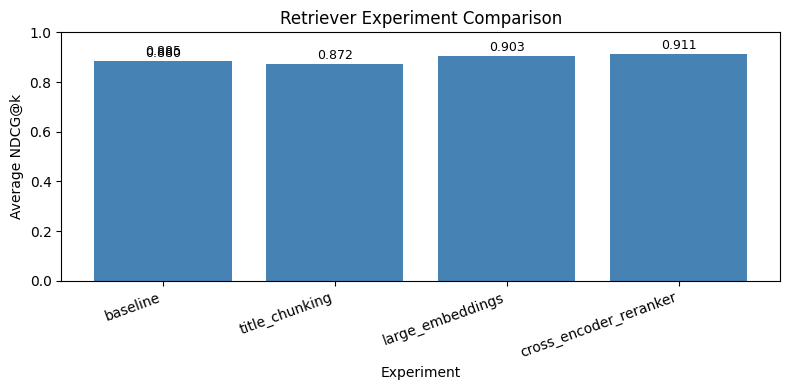

In [13]:
plt.figure(figsize=(8, 4))
bars = plt.bar(retriever_results_df["experiment"], retriever_results_df["avg_ndcg_at_k"], color="steelblue")
plt.title("Retriever Experiment Comparison")
plt.xlabel("Experiment")
plt.ylabel("Average NDCG@k")
plt.ylim(0, max(1.0, retriever_results_df["avg_ndcg_at_k"].max() + 0.05))
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, retriever_results_df["avg_ndcg_at_k"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Generator Results Table
The table below summarizes the generator experiments using the composite LLM-judge evaluation scores.

In [14]:
generator_results_df = pd.DataFrame(generator_experiment_rows)[
    ["experiment", "generator_model", "avg_correctness", "avg_groundedness", "avg_completeness", "avg_generator_score", "valid_evals"]
]

display(generator_results_df)

,experiment,generator_model,avg_correctness,avg_groundedness,avg_completeness,avg_generator_score,valid_evals
0,generator_gpt-5-mini,gpt-5-mini,1.68,1.86,1.69,1.75,100
1,generator_gpt-5-nano,gpt-5-nano,1.66,1.86,1.69,1.74,100


### Generator Results Plot
The bar chart below compares the average composite generator score for each generator model.

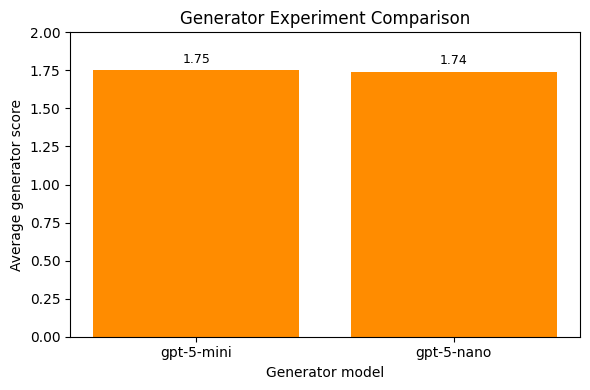

In [15]:
plt.figure(figsize=(6, 4))
bars = plt.bar(generator_results_df["generator_model"], generator_results_df["avg_generator_score"], color="darkorange")
plt.title("Generator Experiment Comparison")
plt.xlabel("Generator model")
plt.ylabel("Average generator score")
plt.ylim(0, max(2.0, generator_results_df["avg_generator_score"].max() + 0.1))

for bar, value in zip(bars, generator_results_df["avg_generator_score"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.03, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 10. Interpretation Template

- **Best retriever setup:** [fill in]
- **Best generator setup:** [fill in]
- **Most important observed trade-off:** [fill in]

## Qualitative Error Analysis
Aggregate metrics summarize overall performance, but they do not explain why the system succeeds or fails on individual questions. The following section inspects a few representative cases to connect retrieval quality, grounding, and answer completeness with concrete system behavior.

In [ ]:
analysis_generator_model = "gpt-5-nano" if nano_results["avg_generator_score"] > mini_results["avg_generator_score"] else "gpt-5-mini"
analysis_rag_chain = nano_rag_chain if analysis_generator_model == "gpt-5-nano" else mini_rag_chain
analysis_limit = min(100, len(qa_pairs))
analysis_k = 4

def classify_qualitative_case(relevance_grades: List[int], retriever_ndcg_at_k: float, generator_scores: dict) -> str:
    """Assign a compact interpretation label to one evaluation example."""
    correctness = generator_scores.get("correctness", 0)
    groundedness = generator_scores.get("groundedness", 0)
    completeness = generator_scores.get("completeness", 0)
    generator_score = generator_scores.get("generator_score", 0.0)

    if 3 not in relevance_grades and any(grade >= 2 for grade in relevance_grades) and generator_score >= 1.4:
        return "Alternative valid evidence retrieved"
    if retriever_ndcg_at_k >= 0.75 and generator_score >= 1.6:
        return "Good retrieval and grounded answer"
    if retriever_ndcg_at_k <= 0.35 and generator_score <= 1.0:
        return "Weak retrieval and weak answer"
    if max(relevance_grades, default=0) >= 2 and correctness >= 1 and completeness <= 1:
        return "Relevant retrieval but incomplete answer"
    if groundedness < correctness:
        return "Grounding issue / possible hallucination"
    return "Mixed behavior"


def collect_qualitative_records(rag_chain, qa_dataset, retriever=None, k: int = 4, limit: int = 100) -> pd.DataFrame:
    """Run the RAG chain on the evaluation set and store per-example inspection data."""
    records = []
    subset = qa_dataset[:limit]

    for item in tqdm(subset, desc="Collecting qualitative examples"):
        question = item["question"]
        gold_answer = item["answer"]
        gold_context = item["context"]
        gold_meta = item.get("meta", "")

        try:
            response = rag_chain.invoke({"input": question})
            context_docs = response.get("context", [])
            if not context_docs and retriever is not None:
                context_docs = retriever.invoke(question)
            context_docs = context_docs[:k]

            generated_answer = response.get("answer", "")
            clean_generated_answer = strip_sources_line(generated_answer)
            retrieved_source_references = format_source_references(context_docs)
            retrieved_chunk_references = []

            retrieved_chunks = []
            retrieved_chunk_snippets = []
            retriever_relevance_grades = []

            for doc in context_docs:
                chunk_text = doc.page_content
                retrieved_chunks.append(chunk_text)
                manual = doc.metadata.get("manual")
                section = doc.metadata.get("section")
                retrieved_chunk_references.append(f"{manual} — {section}" if manual and section else "none")
                retriever_relevance_grades.append(
                    grade_chunk_relevance(
                        question=question,
                        gold_answer=gold_answer,
                        gold_context=gold_context,
                        retrieved_chunk=chunk_text,
                        gold_meta=gold_meta,
                        retrieved_section=doc.metadata.get("section", "")
                    )
                )

                snippet = " ".join(chunk_text.split())
                if len(snippet) > 320:
                    snippet = snippet[:320].rstrip() + "..."
                retrieved_chunk_snippets.append(snippet)

            retriever_ndcg_at_k = round(ndcg_at_k(retriever_relevance_grades, k), 4) if retriever_relevance_grades else 0.0
            context_str = "\n\n".join(doc.page_content for doc in context_docs)

            generator_scores = llm_generator_judge(
                question=question,
                gold_answer=gold_answer,
                retrieved_context=context_str,
                generated_answer=clean_generated_answer
            )
            generator_score = round(
                0.5 * generator_scores.get("correctness", 0) +
                0.4 * generator_scores.get("groundedness", 0) +
                0.1 * generator_scores.get("completeness", 0),
                2
            )
            generator_scores["generator_score"] = generator_score

            records.append({
                "question": question,
                "gold_answer": gold_answer,
                "gold_context": gold_context,
                "gold_meta": item.get("meta", ""),
                "generated_answer": generated_answer,
                "clean_generated_answer": clean_generated_answer,
                "retrieved_chunks": retrieved_chunks,
                "retrieved_chunk_snippets": retrieved_chunk_snippets,
                "retrieved_chunk_references": retrieved_chunk_references,
                "retrieved_source_references": retrieved_source_references,
                "retrieved_sources_text": "; ".join(retrieved_source_references) if retrieved_source_references else "none",
                "retriever_relevance_grades": retriever_relevance_grades,
                "retriever_ndcg_at_k": retriever_ndcg_at_k,
                "max_relevance_grade": max(retriever_relevance_grades, default=0),
                "generator_correctness": generator_scores.get("correctness", 0),
                "generator_groundedness": generator_scores.get("groundedness", 0),
                "generator_completeness": generator_scores.get("completeness", 0),
                "generator_score": generator_score,
                "groundedness_gap": generator_scores.get("correctness", 0) - generator_scores.get("groundedness", 0),
                "has_alternative_valid_evidence": 3 not in retriever_relevance_grades and any(grade >= 2 for grade in retriever_relevance_grades),
                "case_label": classify_qualitative_case(retriever_relevance_grades, retriever_ndcg_at_k, generator_scores),
                "generator_model": analysis_generator_model,
                "k": k
            })
        except Exception as e:
            print(f"Error collecting qualitative record for question '{question}': {e}")

    return pd.DataFrame(records)


qualitative_records_df = collect_qualitative_records(
    rag_chain=analysis_rag_chain,
    qa_dataset=qa_pairs,
    retriever=final_retriever,
    k=analysis_k,
    limit=analysis_limit
)

display(
    qualitative_records_df[[
        "case_label",
        "retriever_ndcg_at_k",
        "generator_score",
        "generator_correctness",
        "generator_groundedness",
        "generator_completeness"
    ]].groupby("case_label", as_index=False).mean().sort_values("generator_score", ascending=False)
)


### Representative Examples
The examples below are selected deliberately from the per-item analysis records rather than sampled at random. This makes it easier to inspect meaningful success and failure patterns.

In [ ]:
def select_representative_examples(records_df: pd.DataFrame, max_examples: int = 5) -> pd.DataFrame:
    """Pick a diverse set of informative success and failure cases."""
    selected_rows = []
    used_questions = set()

    def add_first(candidate_df: pd.DataFrame):
        for _, row in candidate_df.iterrows():
            if row["question"] not in used_questions:
                used_questions.add(row["question"])
                selected_rows.append(row)
                break

    add_first(
        records_df[(records_df["retriever_ndcg_at_k"] >= 0.75) & (records_df["generator_score"] >= 1.6)]
        .sort_values(["generator_score", "retriever_ndcg_at_k"], ascending=[False, False])
    )
    add_first(
        records_df[(records_df["retriever_ndcg_at_k"] <= 0.35) & (records_df["generator_score"] <= 1.0)]
        .sort_values(["generator_score", "retriever_ndcg_at_k"], ascending=[True, True])
    )
    add_first(
        records_df[(records_df["max_relevance_grade"] >= 2) & (records_df["generator_correctness"] >= 1) & (records_df["generator_completeness"] <= 1)]
        .sort_values(["generator_completeness", "retriever_ndcg_at_k"], ascending=[True, False])
    )
    add_first(
        records_df[records_df["generator_groundedness"] < records_df["generator_correctness"]]
        .sort_values(["groundedness_gap", "generator_correctness"], ascending=[False, False])
    )
    add_first(
        records_df[records_df["has_alternative_valid_evidence"]]
        .sort_values(["generator_score", "retriever_ndcg_at_k"], ascending=[False, False])
    )

    if len(selected_rows) < max_examples:
        fallback_df = records_df.sort_values(["generator_score", "retriever_ndcg_at_k"], ascending=[False, False])
        for _, row in fallback_df.iterrows():
            if len(selected_rows) >= max_examples:
                break
            if row["question"] not in used_questions:
                used_questions.add(row["question"])
                selected_rows.append(row)

    return pd.DataFrame(selected_rows)


def display_qualitative_example(row: pd.Series, max_chunks: int = 2):
    """Display one qualitative example in a compact notebook-friendly layout."""
    display(Markdown(f"#### {row['case_label']}"))
    print(f"Question: {row['question']}")
    print(f"Gold answer: {row['gold_answer']}")
    print(f"Generated answer: {row['generated_answer']}")
    print(f"Source references: {row['retrieved_sources_text']}")
    print(f"Retriever grades: {row['retriever_relevance_grades']} | NDCG@{row['k']}: {row['retriever_ndcg_at_k']}")
    print(
        f"Generator scores: correctness={row['generator_correctness']}, "
        f"groundedness={row['generator_groundedness']}, "
        f"completeness={row['generator_completeness']}, "
        f"composite={row['generator_score']}"
    )
    print("Top retrieved chunk snippets:")

    chunk_references = row.get("retrieved_chunk_references", row["retrieved_source_references"])
    for idx, snippet in enumerate(row["retrieved_chunk_snippets"][:max_chunks], start=1):
        source_ref = chunk_references[idx - 1] if idx - 1 < len(chunk_references) else "none"
        print(f"{idx}. {source_ref}")
        print(f"   {snippet}")

    print("-" * 100)


selected_qualitative_examples_df = select_representative_examples(qualitative_records_df, max_examples=5)

display(
    selected_qualitative_examples_df[[
        "case_label",
        "question",
        "retriever_ndcg_at_k",
        "generator_score",
        "retrieved_sources_text"
    ]]
)

for _, row in selected_qualitative_examples_df.iterrows():
    display_qualitative_example(row)


### Qualitative Analysis Notes

- **Most common retrieval failure pattern:** [fill in]
- **Most common generator failure pattern:** [fill in]
- **One example of successful end-to-end behavior:** [fill in]
- **One likely improvement suggested by the observed errors:** [fill in]

## Final Considerations

Recent LLMs with very large context windows reduce some of the traditional pressure on retrieval design, because much larger sets of chunks can now be passed to the generator than was previously possible. In that sense, retrieval optimization is arguably less critical than in earlier RAG systems that had to work under much tighter context limits. However, this does not make retrieval irrelevant. Even with long-context models, retrieval still affects latency, cost, and the signal-to-noise ratio of the final prompt: adding many chunks may increase coverage, but it can also introduce redundancy and distracting context. For this reason, retriever optimization in modern RAG systems should not only be viewed as a way of fitting information into a small window, but also as a way of selecting a large, relevant, and clean evidence set for the generator. In our setup, this means that larger chunk sizes and broader retrieval may work well, but careful retrieval design still remains important for robust answer quality.